__End-to-End Retail Performance and Behavioral Analytics__

## Customers Data

In [1]:
import pandas as pd
import numpy as np

customers_df = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\customers.csv')

print(customers_df.info())
print(customers_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  816 non-null    object 
 1   first_name   816 non-null    object 
 2   last_name    816 non-null    object 
 3   gender       816 non-null    object 
 4   age          776 non-null    float64
 5   signup_date  816 non-null    object 
 6   region       816 non-null    object 
dtypes: float64(1), object(6)
memory usage: 44.8+ KB
None
customer_id     0
first_name      0
last_name       0
gender          0
age            40
signup_date     0
region          0
dtype: int64


In [2]:
# Identify and remove duplicate rows
customers_df = customers_df.drop_duplicates()
print(f"Total records after removing duplicates: {len(customers_df)}")

Total records after removing duplicates: 800


In [3]:
# Fill missing age values with the median of their respective gender group
customers_df['age'] = customers_df['age'].fillna(
    customers_df.groupby('gender')['age'].transform('median')
)

# Optional: If any gender category itself is missing, fill with the global median
global_median = customers_df['age'].median()
customers_df['age'] = customers_df['age'].fillna(global_median)
# Checking for any null values exists
print(customers_df.isnull().sum())

customer_id    0
first_name     0
last_name      0
gender         0
age            0
signup_date    0
region         0
dtype: int64


In [4]:
# Convert signup_date to datetime format
customers_df['signup_date'] = pd.to_datetime(customers_df['signup_date'], dayfirst=True)

# Convert age to integer
customers_df['age'] = customers_df['age'].astype(int)
# Checking for the data types
print(customers_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  800 non-null    object        
 1   first_name   800 non-null    object        
 2   last_name    800 non-null    object        
 3   gender       800 non-null    object        
 4   age          800 non-null    int64         
 5   signup_date  800 non-null    datetime64[ns]
 6   region       800 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 50.0+ KB
None


In [6]:
# Feature Engineering (Age Groups)
# Define a function to categorize ages
def categorize_age(age):
    if age < 18: return 'Under 18'
    elif 18 <= age <= 30: return '18-30'
    elif 31 <= age <= 45: return '31-45'
    elif 46 <= age <= 60: return '46-60'
    else: return '60+'

# Apply the function to create the new column
customers_df['age_group'] = customers_df['age'].apply(categorize_age)
# checking the age_group column
customers_df[['age','age_group']].head(10)

,age,age_group
0,18,18-30
1,36,31-45
2,45,31-45
3,24,18-30
4,50,46-60
5,68,60+
6,47,46-60
7,70,60+
8,48,46-60
9,62,60+


In [8]:
# Clean up strings for better grouping
customers_df['gender'] = customers_df['gender'].str.strip().str.capitalize()
customers_df['region'] = customers_df['region'].str.strip().str.capitalize()

# checking the columns
customers_df.columns

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age',
       'signup_date', 'region', 'age_group'],
      dtype='object')

In [9]:
# Save the final cleaned dataframe
customers_df.to_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\cleaned\customers_cleaned.csv', index=False)
print("Cleaning complete! File saved as 'customers_cleaned.csv'.")

Cleaning complete! File saved as 'customers_cleaned.csv'.


## Products Data

In [12]:
import pandas as pd
import numpy as np

# 1. Load Data
products_df = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\products.csv')
print(products_df.info())
print(products_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1224 non-null   object 
 1   product_name  1224 non-null   object 
 2   category      1224 non-null   object 
 3   brand         1164 non-null   object 
 4   cost_price    1224 non-null   float64
 5   unit_price    1224 non-null   float64
 6   margin_pct    1224 non-null   float64
dtypes: float64(3), object(4)
memory usage: 67.1+ KB
None
product_id       0
product_name     0
category         0
brand           60
cost_price       0
unit_price       0
margin_pct       0
dtype: int64


In [13]:
# Identifying and removing duplicates
products_df = products_df.drop_duplicates()
print(f"Total records after removing duplicates: {len(products_df)}")

Total records after removing duplicates: 1200


In [14]:
# # Clean up strings for better grouping
products_df['category'] = products_df['category'].str.strip().str.capitalize()
products_df['brand'] = products_df['brand'].str.strip().str.title()
products_df['product_name'] = products_df['product_name'].str.strip()

# checking the columns
products_df.columns

Index(['product_id', 'product_name', 'category', 'brand', 'cost_price',
       'unit_price', 'margin_pct'],
      dtype='object')

In [15]:
# Handle Missing Values ( Filling missing brands with 'Unknown')
products_df['brand'] = products_df['brand'].fillna('Unknown')

# Checking for any null values exists
print(products_df.isnull().sum())

product_id      0
product_name    0
category        0
brand           0
cost_price      0
unit_price      0
margin_pct      0
dtype: int64


In [16]:
# Feature Engineering: Recalculate Margin Percentage
# Formula: (Unit Price - Cost Price) / Unit Price
# We round to 4 decimal places for precision
products_df['margin_pct'] = round((products_df['unit_price'] - products_df['cost_price']) / products_df['unit_price'], 4)

# checking the data
products_df.head(10)

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,Brandc,52.75,64.65,0.1841
1,P0001,BrandA Responsibility,Electronics,Brandd,11.20,13.26,0.1554
2,P0002,BrandB Small,Electronics,Brandb,144.62,250.37,0.4224
3,P0003,BrandD Continue,Apparel,Brandd,119.91,219.25,0.4531
4,P0004,BrandA Indeed,Apparel,Brandd,71.35,88.47,0.1935
5,P0005,BrandC Cut,Electronics,Branda,79.09,112.55,0.2973
6,P0006,BrandC Air,Home & kitchen,Branda,147.30,233.12,0.3681
7,P0007,BrandD State,Electronics,Brandc,166.73,276.22,0.3964
8,P0008,BrandC Growth,Apparel,Branda,13.94,18.19,0.2336
9,P0009,BrandC Keep,Electronics,Brandb,173.96,250.87,0.3066


In [17]:
# Save the final cleaned dataframe
products_df.to_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\cleaned\products_cleaned.csv', index=False)
print("Cleaning complete! File saved as 'products_cleaned.csv'.")

Cleaning complete! File saved as 'products_cleaned.csv'.


## Sales data

In [1]:
import pandas as pd
import numpy as np

# Load Data ( products_cleaned.csv for profit calculation)
sales_df = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\salesdata.csv')
products_df = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\Cleaned\products_cleaned.csv')

print(sales_df.info())
print(sales_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       3060 non-null   object 
 1   order_date     3060 non-null   object 
 2   customer_id    3060 non-null   object 
 3   product_id     3060 non-null   object 
 4   store_id       2068 non-null   object 
 5   sales_channel  3060 non-null   object 
 6   quantity       3060 non-null   int64  
 7   unit_price     3060 non-null   float64
 8   discount_pct   3060 non-null   float64
 9   total_amount   3060 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 239.2+ KB
None
order_id           0
order_date         0
customer_id        0
product_id         0
store_id         992
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
dtype: int64


In [2]:
# Remove Duplicates
sales_df = sales_df.drop_duplicates()
print(f"Total records after removing duplicates: {len(sales_df)}")

Total records after removing duplicates: 3000


In [3]:
# Changing Data Types and Fix Invalid Dates (e.g., Feb 29 in a non-leap year)
sales_df['order_date'] = sales_df['order_date'].replace('29-02-2025', '28-02-2025')
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'], dayfirst=True)

# Checking for the data types
print(sales_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3000 non-null   object        
 1   order_date     3000 non-null   datetime64[ns]
 2   customer_id    3000 non-null   object        
 3   product_id     3000 non-null   object        
 4   store_id       2032 non-null   object        
 5   sales_channel  3000 non-null   object        
 6   quantity       3000 non-null   int64         
 7   unit_price     3000 non-null   float64       
 8   discount_pct   3000 non-null   float64       
 9   total_amount   3000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 257.8+ KB
None


In [5]:
# Handle Missing Store IDs
sales_df['store_id'] = sales_df['store_id'].fillna('Online')

# Checking for nulls
print(sales_df.isnull().sum())

order_id         0
order_date       0
customer_id      0
product_id       0
store_id         0
sales_channel    0
quantity         0
unit_price       0
discount_pct     0
total_amount     0
dtype: int64


In [8]:
# 5. Feature Engineering: Recalculate Total Amount & Add Profit
# Total Amount Calculation
sales_df['total_amount'] = round((sales_df['unit_price'] * sales_df['quantity']) * (1 - sales_df['discount_pct']), 2)

# Merge with products to get cost_price
sales_enriched = pd.merge(sales_df, products_df[['product_id', 'cost_price']], on='product_id', how='left')

# Profit Calculation: Revenue - Total Cost
sales_enriched['profit'] = round(sales_enriched['total_amount'] - (sales_enriched['cost_price'] * sales_enriched['quantity']), 2)

# checking the profit column
sales_enriched.head(10)

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount,cost_price,profit
0,O00000,2025-01-31,C0125,P1086,Online,Online,2,80.63,0.05,153.20,69.87,13.46
1,O00001,2025-09-29,C0633,P0973,S042,In-Store,20,209.16,0.05,3974.04,120.11,1571.84
2,O00002,2024-08-29,C0653,P0659,Online,Online,2,218.60,0.10,393.48,173.17,47.14
3,O00003,2025-05-13,C0753,P0666,S014,In-Store,1,78.53,0.20,62.82,65.86,-3.04
4,O00004,2025-07-22,C0627,P0166,S017,In-Store,1,344.93,0.20,275.94,174.83,101.11
5,O00005,2025-12-16,C0716,P0205,S018,In-Store,1,14.31,0.05,13.59,7.90,5.69
6,O00006,2024-09-25,C0532,P1171,S045,In-Store,2,230.62,0.00,461.24,185.92,89.40
7,O00007,2024-09-27,C0515,P0178,S043,In-Store,2,129.07,0.20,206.51,94.08,18.35
8,O00008,2025-03-01,C0456,P0236,S034,In-Store,2,196.93,0.05,374.17,173.04,28.09
9,O00009,2024-12-02,C0174,P0183,Online,Online,3,304.66,0.00,913.98,181.16,370.50


In [10]:
# Standardize Formats
sales_enriched['sales_channel'] = sales_enriched['sales_channel'].str.strip().str.title()

# Checking the data
sales_enriched.head(10)

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount,cost_price,profit
0,O00000,2025-01-31,C0125,P1086,Online,Online,2,80.63,0.05,153.20,69.87,13.46
1,O00001,2025-09-29,C0633,P0973,S042,In-Store,20,209.16,0.05,3974.04,120.11,1571.84
2,O00002,2024-08-29,C0653,P0659,Online,Online,2,218.60,0.10,393.48,173.17,47.14
3,O00003,2025-05-13,C0753,P0666,S014,In-Store,1,78.53,0.20,62.82,65.86,-3.04
4,O00004,2025-07-22,C0627,P0166,S017,In-Store,1,344.93,0.20,275.94,174.83,101.11
5,O00005,2025-12-16,C0716,P0205,S018,In-Store,1,14.31,0.05,13.59,7.90,5.69
6,O00006,2024-09-25,C0532,P1171,S045,In-Store,2,230.62,0.00,461.24,185.92,89.40
7,O00007,2024-09-27,C0515,P0178,S043,In-Store,2,129.07,0.20,206.51,94.08,18.35
8,O00008,2025-03-01,C0456,P0236,S034,In-Store,2,196.93,0.05,374.17,173.04,28.09
9,O00009,2024-12-02,C0174,P0183,Online,Online,3,304.66,0.00,913.98,181.16,370.50


In [11]:
# Save Cleaned Data
sales_enriched.to_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\cleaned\salesdata_cleaned.csv', index=False)
print("Cleaning complete! File saved as 'salesdata_cleaned.csv'.")

Cleaning complete! File saved as 'salesdata_cleaned.csv'.


## Stores Data

In [22]:
import pandas as pd
import numpy as np

# Load Data
stores_df = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\stores.csv')
print(stores_df.info())
print(stores_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   store_id        61 non-null     object 
 1   store_name      61 non-null     object 
 2   store_type      61 non-null     object 
 3   region          61 non-null     object 
 4   city            61 non-null     object 
 5   operating_cost  61 non-null     float64
dtypes: float64(1), object(5)
memory usage: 3.0+ KB
None
store_id          0
store_name        0
store_type        0
region            0
city              0
operating_cost    0
dtype: int64


In [23]:
# Remove Duplicates
stores_df = stores_df.drop_duplicates()
print(f"Total records after removing duplicates: {len(stores_df)}")

Total records after removing duplicates: 60


In [24]:
# Standardize Formats
# Strip spaces and use Title Case for consistency in dashboards
stores_df['store_name'] = stores_df['store_name'].str.strip().str.title()
stores_df['store_type'] = stores_df['store_type'].str.strip().str.title()
stores_df['region'] = stores_df['region'].str.strip().str.title()
stores_df['city'] = stores_df['city'].str.strip().str.title()

print(stores_df.head(10))

  store_id                           store_name store_type region  \
0     S000                    Vincent Inc Store  Franchise   West   
1     S001                     Wilson Inc Store   Flagship   East   
2     S002            Washington-Trujillo Store  Franchise  North   
3     S003               Santana And Sons Store  Franchise  South   
4     S004                 Oconnor-Rhodes Store  Franchise   East   
5     S005                    Mayer-Scott Store   Flagship  North   
6     S006        Stewart, Lowe And Quinn Store   Flagship  North   
7     S007                   Marshall Plc Store   Flagship  North   
8     S008               Mcdaniel-Bennett Store   Flagship  South   
9     S009  Rasmussen, Meyers And Mendoza Store  Franchise   West   

          city  operating_cost  
0      Chicago        62538.56  
1      Chicago        26957.43  
2  Los Angeles        66101.63  
3      Phoenix        71089.40  
4  Los Angeles        40965.26  
5      Houston        14898.94  
6  Los An

In [25]:
# Data Validation
# Ensuring operating costs are valid (no negative values)
invalid_costs = stores_df[stores_df['operating_cost'] <= 0]
if invalid_costs.empty:
    print("All operating costs are valid.")

All operating costs are valid.


In [26]:
# Save Cleaned Data
stores_df.to_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\cleaned\stores_cleaned.csv', index=False)
print("Cleaning complete! File saved as 'stores_cleaned.csv'.")

Cleaning complete! File saved as 'stores_cleaned.csv'.


## Returns Data

In [29]:
import pandas as pd
import numpy as np

# Load Data using a raw string to handle backslashes correctly
file_path = r'D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\returns.csv'
returns_df = pd.read_csv(file_path)

print(returns_df.info())
print(returns_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   return_id      204 non-null    object
 1   order_id       204 non-null    object
 2   return_date    204 non-null    object
 3   return_reason  204 non-null    object
dtypes: object(4)
memory usage: 6.5+ KB
None
return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64


In [31]:
# Remove Duplicates
returns_df = returns_df.drop_duplicates()
print(f"Total records after removing duplicates: {len(returns_df)}")

Total records after removing duplicates: 200


In [32]:
# 3. Datatype formatting and Fix Invalid Dates (Feb 29 correction)
returns_df['return_date'] = returns_df['return_date'].replace('29-02-2025', '28-02-2025')
returns_df['return_date'] = pd.to_datetime(returns_df['return_date'], dayfirst=True)

print(returns_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   return_id      200 non-null    object        
 1   order_id       200 non-null    object        
 2   return_date    200 non-null    datetime64[ns]
 3   return_reason  200 non-null    object        
dtypes: datetime64[ns](1), object(3)
memory usage: 7.8+ KB
None


In [33]:
# 4. Standardize Text Formats
returns_df['return_reason'] = returns_df['return_reason'].str.strip().str.title()

print(returns_df.head(10))

  return_id order_id return_date     return_reason
0     R0000   O02237  2025-03-05         Defective
1     R0001   O01700  2025-03-18         Defective
2     R0002   O01451  2025-02-18     Late Delivery
3     R0003   O02759  2024-10-26         Defective
4     R0004   O00415  2025-08-06  No Longer Needed
5     R0005   O02110  2025-06-01     Late Delivery
6     R0006   O02845  2025-11-11  No Longer Needed
7     R0007   O00362  2025-03-01         Defective
8     R0008   O01002  2025-03-28         Defective
9     R0009   O02036  2025-01-13     Late Delivery


In [36]:
# Save Cleaned Data
file_path1 = r'D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\cleaned\returns_cleaned.csv'
returns_df.to_csv(file_path1, index=False)

print("Cleaning complete! Final file saved as 'returns_cleaned.csv'.")

Cleaning complete! Final file saved as 'returns_cleaned.csv'.


## Exploratory Data Analysis

#### Monthly Revenue and Profit Trends

Monthly trends chart saved as 'monthly_trends.png'.


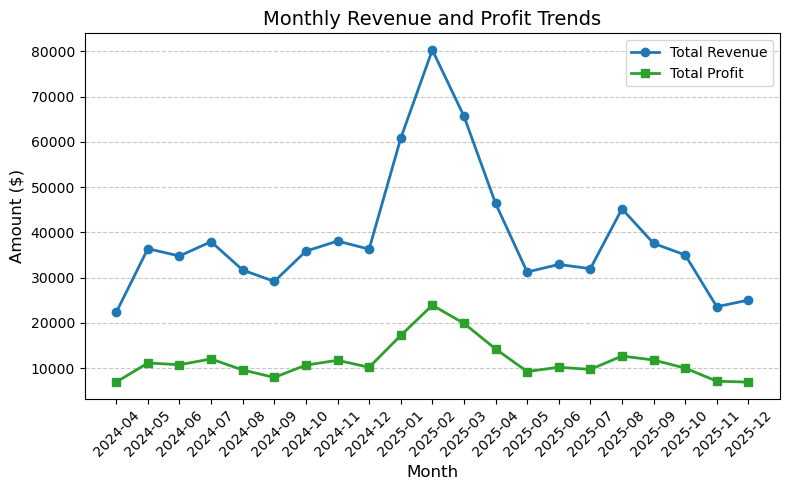

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the cleaned sales data
sales = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\Cleaned\salesdata_cleaned.csv')

# 2. Pre-process dates
sales['order_date'] = pd.to_datetime(sales['order_date'])
sales['month_year'] = sales['order_date'].dt.to_period('M').astype(str)

# 3. Group by month
monthly_data = sales.groupby('month_year')[['total_amount', 'profit']].sum().reset_index()

# 4. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(monthly_data['month_year'], monthly_data['total_amount'], marker='o', label='Total Revenue', color='#1f77b4', linewidth=2)
plt.plot(monthly_data['month_year'], monthly_data['profit'], marker='s', label='Total Profit', color='#2ca02c', linewidth=2)

# 5. Formatting
plt.title('Monthly Revenue and Profit Trends', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# 6. Save and show
plt.savefig('monthly_trends.png')
print("Monthly trends chart saved as 'monthly_trends.png'.")

#### Top 10 Customers by Revenue

Top customers chart saved as 'top_customers.png'.


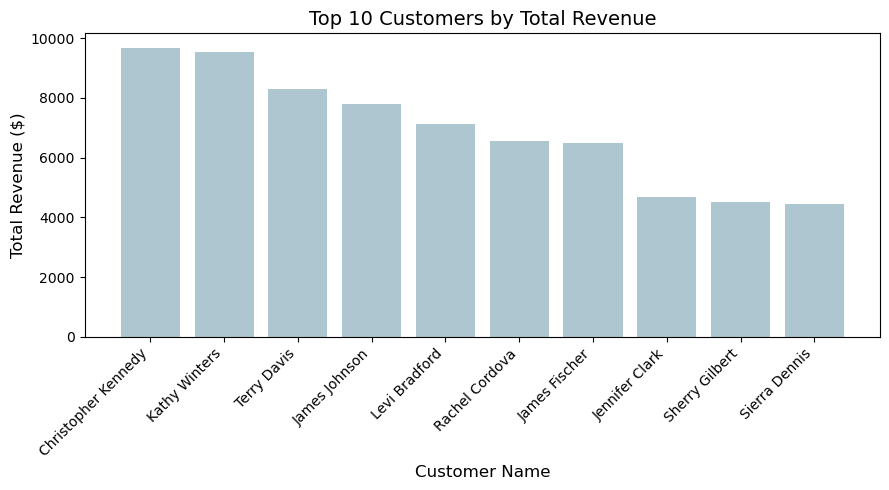

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the cleaned datasets
sales = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\Cleaned\salesdata_cleaned.csv')
customers = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\Cleaned\customers_cleaned.csv')

# 2. Calculate total revenue per customer
customer_rev = sales.groupby('customer_id')['total_amount'].sum().reset_index()

# 3. Merge with customer names
top_customers = customer_rev.merge(customers[['customer_id', 'first_name', 'last_name']], on='customer_id')
top_customers['full_name'] = top_customers['first_name'] + ' ' + top_customers['last_name']

# 4. Sort and take the top 10
top_customers = top_customers.sort_values(by='total_amount', ascending=False).head(10)

# 5. Create the bar chart
plt.figure(figsize=(9, 5))
plt.bar(top_customers['full_name'], top_customers['total_amount'], color='#aec6cf')

# 6. Formatting
plt.title('Top 10 Customers by Total Revenue', fontsize=14)
plt.xlabel('Customer Name', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 7. Save
plt.savefig('top_customers.png')
print("Top customers chart saved as 'top_customers.png'.")

#### Revenue by Product Category

Category performance chart saved as 'category_performance.png'.


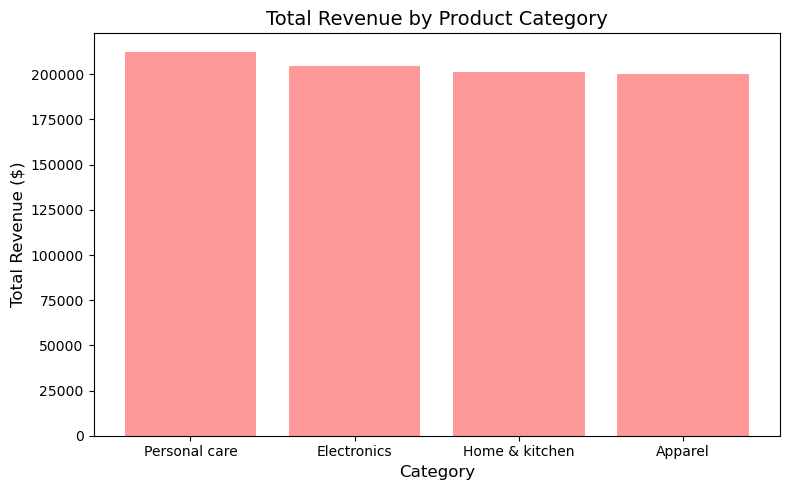

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the cleaned datasets
sales = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\Cleaned\salesdata_cleaned.csv')
products = pd.read_csv('D:\Data_analytics_ExcellenC\Project 2\End-to-End Retail Performance and Behavioral Analytics\Data\Raw\Cleaned\products_cleaned.csv')

# 2. Merge sales with product categories
sales_enriched = sales.merge(products[['product_id', 'category']], on='product_id')

# 3. Calculate revenue by category
cat_performance = sales_enriched.groupby('category')['total_amount'].sum().sort_values(ascending=False).reset_index()

# 4. Create the bar chart
plt.figure(figsize=(8, 5))
plt.bar(cat_performance['category'], cat_performance['total_amount'], color='#ff9999')

# 5. Formatting
plt.title('Total Revenue by Product Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.tight_layout()

# 6. Save
plt.savefig('category_performance.png')
print("Category performance chart saved as 'category_performance.png'.")